## Model Selecton and Cross Validation

In [1]:
import sklearn as sk
import pandas as pd
import numpy as np

### Data Importing

In [2]:
import pandas as pd
loans=pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Credit_Risk_Cleaned/Cleaned_cs_training.csv")

In [3]:
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Sr_No                   150000 non-null  int64  
 1   SeriousDlqin2yrs        150000 non-null  int64  
 2   util_new                150000 non-null  float64
 3   age_new                 150000 non-null  int64  
 4   num_30_59_dpd_new       150000 non-null  int64  
 5   DebtRatio_new_ind       150000 non-null  int64  
 6   DebtRatio_new           150000 non-null  float64
 7   MonthlyIncome_ind       150000 non-null  int64  
 8   MonthlyIncome_new       150000 non-null  int64  
 9   Open_Credit_lines_new   150000 non-null  int64  
 10  num_90_dpd_new          150000 non-null  int64  
 11  Real_estate_loans_new   150000 non-null  int64  
 12  num_60_dpd_new          150000 non-null  int64  
 13  NumberOfDependents_new  150000 non-null  int64  
dtypes: float64(2), int64(12)
memory

In [4]:
import statsmodels.formula.api as sm

risk_model=sm.logit(formula="SeriousDlqin2yrs ~ util_new+age_new+num_30_59_dpd_new+DebtRatio_new_ind+DebtRatio_new+MonthlyIncome_ind+MonthlyIncome_new+Open_Credit_lines_new+num_90_dpd_new+Real_estate_loans_new+num_60_dpd_new+NumberOfDependents_new", data=loans)
results=risk_model.fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.193444
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               150000
Model:                          Logit   Df Residuals:                   149987
Method:                           MLE   Df Model:                           12
Date:                Fri, 23 Jan 2026   Pseudo R-squ.:                  0.2117
Time:                        15:38:06   Log-Likelihood:                -29017.
converged:                       True   LL-Null:                       -36808.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -3.5074      0.080    -43.799      0.000      -3.664      

### Sensitivity and Specificity

In [5]:
###predict the variable active customer from logistic fit####
predictions = results.predict()
print(predictions[0:10])
len(predictions)

[0.16607312 0.03823372 0.0952147  0.02527758 0.08018387 0.0839387
 0.02279788 0.01345062 0.02385612 0.07162216]


150000

In [6]:
### Converting predicted values into classes using threshold
threshold=0.5
predicted_class1=[ 0 if x < threshold else 1 for x in predictions]
print(predicted_class1[0:10])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [7]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(loans["SeriousDlqin2yrs"],predicted_class1)
print('Confusion Matrix : \n', cm1)

total1=sum(sum(cm1))
#####from confusion matrix calculate accuracy
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1*100)
# Here specificity plays a major role as it predicts the seriously Deliquent(Bad) Customer as good
# So we need to improve specificity percentage

Confusion Matrix : 
 [[138965   1009]
 [  8526   1500]]
Accuracy :  0.9364333333333333
Sensitivity :  0.9927915184248504
Specificity :  14.961101137043686


### Threshold
(adjusts the probability cutoff (default is 0.5) for classifying an instance as positive)

In [8]:
###Sensitivity vs Specificity with Different Thresholds
### Converting predicted values into classes using new threshold
threshold=0.2
predicted_class1=[ 0 if x < threshold else 1 for x in predictions]

#Change in Confusion Matrix, Accuracy and Sensitivity-Specificity
#Confusion matrix, Accuracy, sensitivity and specificity
cm1 = confusion_matrix(loans["SeriousDlqin2yrs"],predicted_class1)
print('Confusion Matrix : \n', cm1)

total1=sum(sum(cm1))
#####from confusion matrix calculate accuracy
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

# for threshold=0.2, specificity is 35% with accuracy of 92%
# for threshold=0.8, specificity is 6% with accuracy of 93%
## In this case we can choose threshold=0.2 as it gives more specificity

Confusion Matrix : 
 [[135485   4489]
 [  6491   3535]]
Accuracy :  0.9268
Sensitivity :  0.9679297583836999
Specificity :  0.3525832834629962


### Precision, Recall & F1 Score

In [9]:
predictions = results.predict()
### Converting predicted values into classes using threshold
threshold=0.5
predicted_class1=[ 0 if x < threshold else 1 for x in predictions]

cm1 = confusion_matrix(loans["SeriousDlqin2yrs"],predicted_class1)
print('Confusion Matrix : \n', cm1)

total1=sum(sum(cm1))
#####from confusion matrix calculate accuracy
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)


Precision_Class0 = cm1[0,0]/(cm1[0,0]+cm1[1,0])
print('Precision_Class0 : ', Precision_Class0 )

Recall_Class0 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Recall_Class0 : ', Recall_Class0 )

F1_Class0 = 2/((1/Precision_Class0)+(1/Recall_Class0))
print('F1_Class0 : ', F1_Class0 )


Precision_Class1 = cm1[1,1]/(cm1[0,1]+cm1[1,1])
print('Precision_Class1 : ', Precision_Class1 )

Recall_Class1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Recall_Class1 : ', Recall_Class1 )

F1_Class1 = 2/((1/Precision_Class1)+(1/Recall_Class1))
print('F1_Class1 : ', F1_Class1 )


Confusion Matrix : 
 [[138965   1009]
 [  8526   1500]]
Accuracy :  0.9364333333333333
Precision_Class0 :  0.9421930829677743
Recall_Class0 :  0.9927915184248504
F1_Class0 :  0.9668307446123875
Precision_Class1 :  0.5978477481068155
Recall_Class1 :  0.14961101137043686
F1_Class1 :  0.23932987634623054


In [10]:
# Another way to calculate Precision, Recall, F1-Score using sklearn metrics

from sklearn.metrics import classification_report
print(classification_report(loans["SeriousDlqin2yrs"],predicted_class1))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97    139974
           1       0.60      0.15      0.24     10026

    accuracy                           0.94    150000
   macro avg       0.77      0.57      0.60    150000
weighted avg       0.92      0.94      0.92    150000



### ROC (Receiver Operating Characteristic)

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

actual = loans["SeriousDlqin2yrs"]
false_positive_rate, true_positive_rate, thresholds = roc_curve(actual, predictions)
print("false_positive_rate", false_positive_rate)
print("true_positive_rate", true_positive_rate)
print("thresholds", thresholds)

false_positive_rate [0.         0.         0.         ... 0.99996428 0.99998571 1.        ]
true_positive_rate [0.00000000e+00 9.97406742e-05 1.99481348e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
thresholds [       inf 0.99992317 0.99977919 ... 0.00518339 0.00518171 0.00502586]


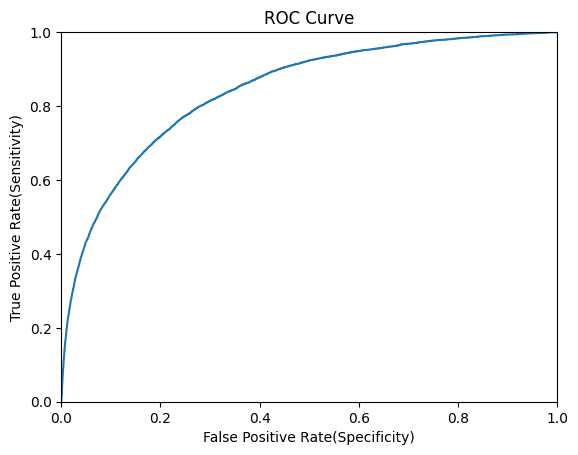

In [12]:
import matplotlib.pyplot as plt
plt.title('ROC Curve')
#Drawing ROC Curve
plt.plot(false_positive_rate, true_positive_rate)

#X and Y  Axis Limits
plt.xlim([-0,1])
plt.ylim([-0,1])

# Labels
plt.ylabel('True Positive Rate(Sensitivity)')
plt.xlabel('False Positive Rate(Specificity)')
plt.show()

### AUC

In [13]:
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

0.8419745700913576

## Handling Class Imbalance

In [14]:
print("Actual Data :", loans.shape)

#Frequency count on target column
freq=loans['SeriousDlqin2yrs'].value_counts()
print(freq)
print((freq/freq.sum())*100)  # Frequency count in percentage

#Classwise data
credit_risk_class0 = loans[loans['SeriousDlqin2yrs'] == 0]
credit_risk_class1 = loans[loans['SeriousDlqin2yrs'] == 1]

print("Class0 Actual :", credit_risk_class0.shape)
print("Class1 Actual  :", credit_risk_class1.shape)

Actual Data : (150000, 14)
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    93.316
1     6.684
Name: count, dtype: float64
Class0 Actual : (139974, 14)
Class1 Actual  : (10026, 14)


### Undersampling and Oversampling

In [15]:
##Undersampling of class-0
## Consider half(50% = 0.5) of class-0
credit_risk_class0_under = credit_risk_class0.sample(int(0.5*len(credit_risk_class0))) 
print("Class0 Undersample :", credit_risk_class0_under.shape)

##Oversampling of Class-1
# Lets increase the size by four times
credit_risk_class1_over = credit_risk_class1.sample(4*len(credit_risk_class1),replace=True)
print("Class1 Oversample :", credit_risk_class1_over.shape)

#Concatenate to create the final balanced data
credit_risk_balanced=pd.concat([credit_risk_class0_under,credit_risk_class1_over])
print("Final Balannced Data :", credit_risk_balanced.shape)

#Frequency count on target column in the balanced data
freq=credit_risk_balanced['SeriousDlqin2yrs'].value_counts()
print(freq)
print((freq/freq.sum())*100)   # in percentage

Class0 Undersample : (69987, 14)
Class1 Oversample : (40104, 14)
Final Balannced Data : (110091, 14)
SeriousDlqin2yrs
0    69987
1    40104
Name: count, dtype: int64
SeriousDlqin2yrs
0    63.571954
1    36.428046
Name: count, dtype: float64


In [16]:
# After getting balanced data, we'll redo the logistic regression & check model's performance metrics.

model_formula="SeriousDlqin2yrs ~ util_new + age_new + num_30_59_dpd_new + DebtRatio_new_ind + DebtRatio_new + MonthlyIncome_ind + MonthlyIncome_new + Open_Credit_lines_new + num_90_dpd_new + Real_estate_loans_new + num_60_dpd_new + NumberOfDependents_new"
risk_model=sm.logit(model_formula, data=credit_risk_balanced)    # the balanced dataset is passed here
results=risk_model.fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.474890
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               110091
Model:                          Logit   Df Residuals:                   110078
Method:                           MLE   Df Model:                           12
Date:                Fri, 23 Jan 2026   Pseudo R-squ.:                  0.2759
Time:                        15:38:08   Log-Likelihood:                -52281.
converged:                       True   LL-Null:                       -72202.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1.5352      0.052    -29.302      0.000      -1.638      

In [17]:
## Updated Sensitivity and Specificity after balancing the data

predictions = results.predict()
threshold=0.5
predicted_class1=[ 0 if x < threshold else 1 for x in predictions]

cm1 = confusion_matrix(credit_risk_balanced["SeriousDlqin2yrs"],predicted_class1)
print('Confusion Matrix : \n', cm1)

total1=sum(sum(cm1))
#####from confusion matrix calculate accuracy
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

# specificity value has improved from 14% to 56% after balancing the data on having threshold=0.5

Confusion Matrix : 
 [[63513  6474]
 [17599 22505]]
Accuracy :  0.7813354406808912
Sensitivity :  0.9074971066055124
Specificity :  0.5611659684819469


## SMOTE for handling class imbalance

In [18]:
# Analysis on Original Data
print("Actual Data :", loans.shape)

#Frequency count on target column
freq=loans['SeriousDlqin2yrs'].value_counts()
print(freq)
print((freq/freq.sum())*100)

#Classwise data
credit_risk_class0 = loans[loans['SeriousDlqin2yrs'] == 0]
credit_risk_class1 = loans[loans['SeriousDlqin2yrs'] == 1]

print("Class0 Actual :", credit_risk_class0.shape)
print("Class1 Actual  :", credit_risk_class1.shape)

Actual Data : (150000, 14)
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    93.316
1     6.684
Name: count, dtype: float64
Class0 Actual : (139974, 14)
Class1 Actual  : (10026, 14)


In [19]:
print(loans.columns)
X_train=loans.iloc[:,2:]   # Selecting every row and colums from 'util_new' (3rd column having index 2)
y_train=loans["SeriousDlqin2yrs"]
print(X_train.shape)
print(y_train.shape)

Index(['Sr_No', 'SeriousDlqin2yrs', 'util_new', 'age_new', 'num_30_59_dpd_new',
       'DebtRatio_new_ind', 'DebtRatio_new', 'MonthlyIncome_ind',
       'MonthlyIncome_new', 'Open_Credit_lines_new', 'num_90_dpd_new',
       'Real_estate_loans_new', 'num_60_dpd_new', 'NumberOfDependents_new'],
      dtype='str')
(150000, 12)
(150000,)


In [21]:
# Applying SMOTE technique to balance the data
from imblearn.over_sampling import SMOTE        # imblearn is imbalanced-learn library
smote = SMOTE(random_state = 2)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

import collections
print("Before SMOTE", collections.Counter(y_train))
print("After SMOTE", collections.Counter(y_train_smote))
# this'll balance the data by oversampling the minority class but 
# now the minority class have same number of records as majority class which is not that helpful 

Before SMOTE Counter({0: 139974, 1: 10026})
After SMOTE Counter({0: 139974, 1: 139974})


In [22]:
# Here, using 'sampling_strategy' param to set the desired ratio of minority to majority class
# automatically the previous code set it to 1.0 or 100%
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy=0.6, random_state = 2)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

import collections
print("Before SMOTE", collections.Counter(y_train))
print("After SMOTE", collections.Counter(y_train_smote))

Before SMOTE Counter({0: 139974, 1: 10026})
After SMOTE Counter({0: 139974, 1: 83984})


In [ ]:
loans_smote=X_train_smote
loans_smote["SeriousDlqin2yrs"]=y_train_smote

In [ ]:
# Rebuilding the logistic model on SMOTE data
model_formula="SeriousDlqin2yrs ~ util_new + age_new + num_30_59_dpd_new + DebtRatio_new_ind + DebtRatio_new + MonthlyIncome_ind + MonthlyIncome_new + Open_Credit_lines_new + num_90_dpd_new + Real_estate_loans_new + num_60_dpd_new + NumberOfDependents_new"

credit_risk_balanced=loans_smote
risk_model=sm.logit(model_formula, data=credit_risk_balanced)
results=risk_model.fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.502359
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               223958
Model:                          Logit   Df Residuals:                   223945
Method:                           MLE   Df Model:                           12
Date:                Sun, 18 Jan 2026   Pseudo R-squ.:                  0.2406
Time:                        21:19:46   Log-Likelihood:            -1.1251e+05
converged:                       True   LL-Null:                   -1.4816e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0.4473      0.037    -12.144      0.000      -0.519      

In [ ]:
## Updated Sensitivity and Specificity after balancing the data
predictions = results.predict()
threshold=0.5
predicted_class1=[ 0 if x < threshold else 1 for x in predictions]

cm1 = confusion_matrix(credit_risk_balanced["SeriousDlqin2yrs"],predicted_class1)
print('Confusion Matrix : \n', cm1)

total1=sum(sum(cm1))
#####from confusion matrix calculate accuracy
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)

sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

# Improves the specificity from 14% to 58% on threshold=0.5

Confusion Matrix : 
 [[119789  20185]
 [ 35012  48972]]
Accuracy :  0.7535386099179311
Sensitivity :  0.8557946475774072
Specificity :  0.5831110687750047


## Bias Variance TradeOff

### Model with huge Variance - Overfitted model

In [23]:
Fiber_df=pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Fiberbits/Fiberbits_v1.csv")

from sklearn.model_selection import train_test_split
from sklearn import tree

features = list(Fiber_df.drop(['active_cust'], axis=1).columns)
X = np.array(Fiber_df[features])
y = np.array(Fiber_df['active_cust'])

#Splitting the dataset into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8 , random_state=333)     # Used Hold Out Cross Validation Method
#Build the best model(1% error) model on training data.
tree_model = tree.DecisionTreeClassifier()
tree_model.fit(X_train,y_train)

train_acc= tree_model.score(X_train,y_train)
print("train_accuracy", train_acc)

test_acc= tree_model.score(X_test,y_test)
print("test_accuracy", test_acc)

train_accuracy 0.9999625
test_accuracy 0.8876


### Model with huge Bias - underfitted model

In [ ]:
tree_model = tree.DecisionTreeClassifier(max_depth=1)
tree_model.fit(X_train,y_train)

train_acc= tree_model.score(X_train,y_train)
print("train_accuracy", train_acc)

test_acc= tree_model.score(X_test,y_test)
print("test_accuracy", test_acc)

train_accuracy 0.813
test_accuracy 0.81495


### Holdout data Cross Validation

In [ ]:
tree_model = tree.DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train,y_train)

train_acc= tree_model.score(X_train,y_train)
print("train_accuracy", train_acc)

test_acc= tree_model.score(X_test,y_test)
print("test_accuracy", test_acc)
# accuracy change is due to increase in depth of tree which improves the model from underfitting

train_accuracy 0.8936625
test_accuracy 0.8961


### K-Fold Cross Validation

In [ ]:
X = np.array(Fiber_df[features])
y = np.array(Fiber_df['active_cust'])

tree_KF = tree.DecisionTreeClassifier()

#K-Fold cross validation where k=10 folds.
from sklearn.model_selection import KFold
kfold_models = KFold(n_splits=10)  

from sklearn import model_selection
scores = model_selection.cross_val_score(tree_KF,X, y,cv=kfold_models)
print(scores)
print("Avg K-Fold Accuracy", scores.mean())

[0.9098 0.879  0.8608 0.894  0.8789 0.8504 0.8207 0.9056 0.8655 0.8619]
Avg K-Fold Accuracy 0.87266
